# Kanban Board for AI Operations

**Module 04 — Business Case & AI Project Management — Exercise 03**

Design a Kanban board for the continuous-operations phase of a deployed AI system. The exercise lands on the methodology layer described in [`notes/07_project_management_methodologies.md`](../notes/07_project_management_methodologies.md) and on the post-deployment work surfaced by [`notes/02_kpis_lifecycle_drift.md`](../notes/02_kpis_lifecycle_drift.md): drift response, retraining, bias audits, documentation, regulatory updates. These tasks arrive unpredictably and continuously, which is exactly the shape of work Kanban is built for. Scrum-style sprint planning would force-fit irregular operational work into fixed timeboxes; Kanban accepts the irregularity and optimises throughput instead.

## Scenario

The AI system is live in production. The owning team handles a continuous stream of work:
- User reports on inconsistent or biased predictions.
- Bug fixes and patches.
- Model retraining cycles and validation.
- Refactoring of data pipelines.
- Documentation updates, compliance and audit tasks.
- Improvement requests from product and from internal stakeholders.

## What the exercise produces

- A Kanban board with four columns: **Todo / Doing / Review / Done**.
- Around 8-10 representative operational cards distributed across the columns to reflect a realistic snapshot.
- A defined **WIP limit on Doing** with rationale (team size, Little's Law intuition).
- A short narrative on the workflow being represented and the bottleneck this snapshot exposes.

## Part 1 — Encode the board

Cards as a list of `(title, category)` tuples. The category tag is not on the original brief but it lets us aggregate later — by-card-type analysis is what tells you whether the team is drowning in bug fixes vs spending time on model improvements.

Each column gets a colour matching the standard Kanban convention: cool/neutral for the queue, warm for in-flight, secondary warm for review, green for completed.

In [1]:
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.style.use('seaborn-v0_8-whitegrid')

BOARD = {
    'Todo': {
        'color':  '#8b5cf6',
        'accent': '#c4b5fd',
        'cards': [
            ('User reports on inconsistent predictions',  'bug-report'),
            ('Improve readability of AI outputs',          'ux-improvement'),
            ('Preliminary bias analysis on training data', 'data-quality'),
            ('Internal model audit requested',             'governance'),
            ('Reported bug not yet reproduced',            'bug-report'),
            ('Evaluate upgrade of AI dependencies',        'maintenance'),
        ],
    },
    'Doing': {
        'color':  '#eab308',
        'accent': '#fde68a',
        'cards': [
            ('Fix classification bug',                     'bug-fix'),
            ('Model retraining run (quarterly cycle)',     'model-lifecycle'),
            ('Refactor data preprocessing pipeline',       'maintenance'),
            ('Align outputs with new internal policy',     'governance'),
        ],
    },
    'Review': {
        'color':  '#f97316',
        'accent': '#fdba74',
        'cards': [
            ('Bug fix ready for QA',                       'bug-fix'),
            ('New model version validation',               'model-lifecycle'),
            ('Explainability check on new outputs',        'governance'),
            ('Audit documentation review',                 'governance'),
        ],
    },
    'Done': {
        'color':  '#22c55e',
        'accent': '#86efac',
        'cards': [
            ('Critical bug fixed and released',            'bug-fix'),
            ('AI model updated to v2.3',                   'model-lifecycle'),
            ('Documentation refresh published',            'maintenance'),
            ('Regulatory-compliance updates completed',    'governance'),
            ('Inference-latency optimisation deployed',    'performance'),
        ],
    },
}

WIP_LIMIT_DOING = 3  # one card per engineer on a 3-person team; Little's Law intuition

print('=' * 80)
print('KANBAN BOARD — AI OPERATIONS')
print('=' * 80)
for col_name, col in BOARD.items():
    print(f"\n{col_name}  |  {len(col['cards'])} cards")
    for title, cat in col['cards']:
        print(f"  - [{cat:<15s}] {title}")
print(f"\nWIP limit on Doing: {WIP_LIMIT_DOING}")

KANBAN BOARD — AI OPERATIONS

Todo  |  6 cards
  - [bug-report     ] User reports on inconsistent predictions
  - [ux-improvement ] Improve readability of AI outputs
  - [data-quality   ] Preliminary bias analysis on training data
  - [governance     ] Internal model audit requested
  - [bug-report     ] Reported bug not yet reproduced
  - [maintenance    ] Evaluate upgrade of AI dependencies

Doing  |  4 cards
  - [bug-fix        ] Fix classification bug
  - [model-lifecycle] Model retraining run (quarterly cycle)
  - [maintenance    ] Refactor data preprocessing pipeline
  - [governance     ] Align outputs with new internal policy

Review  |  4 cards
  - [bug-fix        ] Bug fix ready for QA
  - [model-lifecycle] New model version validation
  - [governance     ] Explainability check on new outputs
  - [governance     ] Audit documentation review

Done  |  5 cards
  - [bug-fix        ] Critical bug fixed and released
  - [model-lifecycle] AI model updated to v2.3
  - [maintenance   

## Part 2 — Render the board

The board is drawn with `FancyBboxPatch` for the rounded card outlines. Each column carries its header (name + count), a coloured underline, and the cards stacked top-to-bottom. The Doing column gets a small badge showing the WIP limit; if the column is over-limit, the badge turns red.

Card text is wrapped to the column width with `textwrap.wrap`.

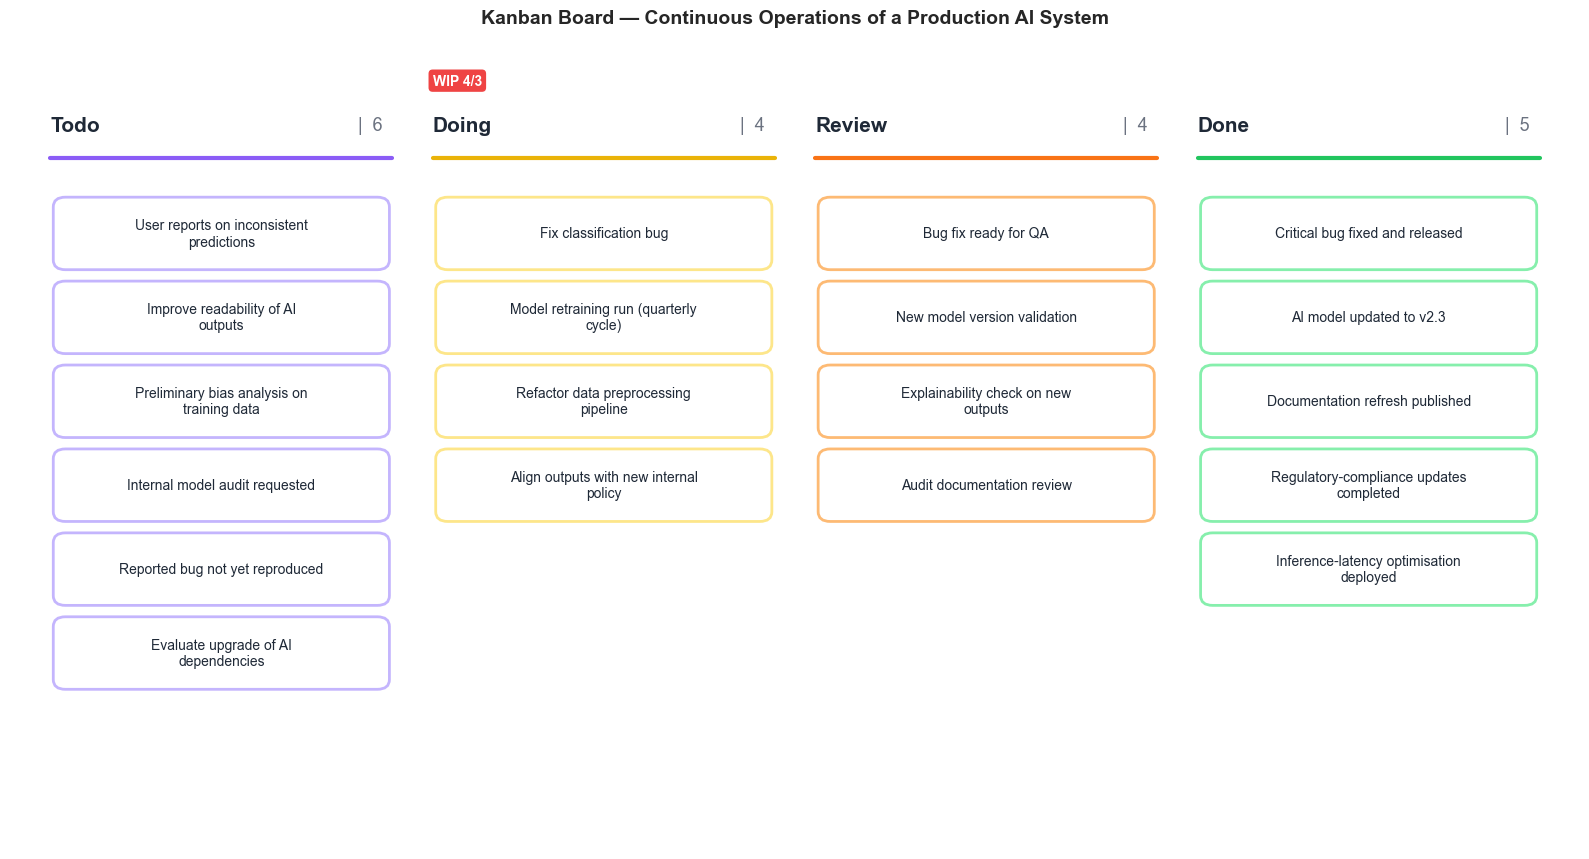

Saved: 03_ex_kanban_board_ai_operations.png


In [2]:
COL_WIDTH = 3.4
COL_GAP = 0.4
CARD_HEIGHT = 0.85
CARD_GAP = 0.18
WRAP_WIDTH = 32

max_cards = max(len(c['cards']) for c in BOARD.values())
fig_height = 2.5 + max_cards * (CARD_HEIGHT + CARD_GAP)
fig, ax = plt.subplots(figsize=(16, fig_height))

for i, (col_name, col) in enumerate(BOARD.items()):
    x = i * (COL_WIDTH + COL_GAP)
    n = len(col['cards'])

    if col_name == 'Doing':
        over_limit = n > WIP_LIMIT_DOING
        badge_color = '#ef4444' if over_limit else '#16a34a'
        ax.text(x, 1.25, f'WIP {n}/{WIP_LIMIT_DOING}',
                fontsize=10, ha='left', va='center',
                color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor=badge_color, edgecolor='none'))

    header_color = col['color']
    ax.text(x, 0.7, col_name, fontsize=15, fontweight='bold',
            ha='left', va='center', color='#1f2937')
    ax.text(x + COL_WIDTH - 0.1, 0.7, f'|  {n}', fontsize=13,
            ha='right', va='center', color='#6b7280')
    ax.plot([x, x + COL_WIDTH], [0.3, 0.3], color=header_color, linewidth=3)

    for j, (card_title, _cat) in enumerate(col['cards']):
        y_top = -0.2 - j * (CARD_HEIGHT + CARD_GAP)
        card = FancyBboxPatch(
            (x + 0.05, y_top - CARD_HEIGHT),
            COL_WIDTH - 0.1, CARD_HEIGHT,
            boxstyle='round,pad=0.02,rounding_size=0.12',
            linewidth=2, edgecolor=col['accent'], facecolor='white',
        )
        ax.add_patch(card)
        wrapped = '\n'.join(textwrap.wrap(card_title, width=WRAP_WIDTH))
        ax.text(x + COL_WIDTH/2, y_top - CARD_HEIGHT/2, wrapped,
                ha='center', va='center', fontsize=10, color='#1f2937')

ax.set_xlim(-0.4, 4 * (COL_WIDTH + COL_GAP))
ax.set_ylim(-fig_height + 0.5, 1.7)
ax.axis('off')
fig.suptitle('Kanban Board — Continuous Operations of a Production AI System',
             fontsize=14, fontweight='bold', y=0.985)

plt.tight_layout()
plt.savefig('03_ex_kanban_board_ai_operations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_ex_kanban_board_ai_operations.png')

## Part 3 — Flow metrics and bottleneck check

Two diagnostics on the snapshot:

1. **WIP check on Doing.** A WIP limit of 3 for a 3-engineer team follows the rule of thumb of roughly one active card per engineer, which keeps context switching low and surfaces blockers fast (Little's Law: cycle time ∝ WIP / throughput, so unbounded WIP destroys cycle time without raising throughput).
2. **Card-type mix per column.** If the team's `Doing` column is dominated by bug fixes, the modelling roadmap is being starved; if `Done` is mostly governance, the team is paying for compliance debt rather than delivering value.

In [3]:
rows = [
    {'column': col_name, 'category': cat, 'card': title}
    for col_name, col in BOARD.items()
    for title, cat in col['cards']
]
df = pd.DataFrame(rows)

col_counts = df['column'].value_counts().reindex(['Todo', 'Doing', 'Review', 'Done'])
cat_by_col = pd.crosstab(df['category'], df['column'])\
                .reindex(columns=['Todo', 'Doing', 'Review', 'Done'], fill_value=0)

print('=' * 80)
print('FLOW DIAGNOSTICS')
print('=' * 80)
print('\nCards per column:')
for c, n in col_counts.items():
    print(f'  {c:<8s} {n}')

doing_n = col_counts['Doing']
if doing_n > WIP_LIMIT_DOING:
    print(f"\nWIP CHECK: Doing has {doing_n} cards vs limit {WIP_LIMIT_DOING} — OVER LIMIT.")
    print('Action: stop pulling from Todo. Swarm to clear one Doing card.')
elif doing_n == WIP_LIMIT_DOING:
    print(f"\nWIP CHECK: Doing at exact limit ({doing_n}/{WIP_LIMIT_DOING}). Healthy but no slack.")
else:
    print(f"\nWIP CHECK: Doing within limit ({doing_n}/{WIP_LIMIT_DOING}).")

review_n = col_counts['Review']
if review_n >= doing_n:
    print(f"Bottleneck signal: Review ({review_n}) >= Doing ({doing_n}) — review is constraining flow.")
    print('Action: prioritise Review work over starting new Doing items.')

print('\nCard mix by column (counts):')
print(cat_by_col.to_string())

FLOW DIAGNOSTICS

Cards per column:
  Todo     6
  Doing    4
  Review   4
  Done     5

WIP CHECK: Doing has 4 cards vs limit 3 — OVER LIMIT.
Action: stop pulling from Todo. Swarm to clear one Doing card.
Bottleneck signal: Review (4) >= Doing (4) — review is constraining flow.
Action: prioritise Review work over starting new Doing items.

Card mix by column (counts):
column           Todo  Doing  Review  Done
category                                  
bug-fix             0      1       1     1
bug-report          2      0       0     0
data-quality        1      0       0     0
governance          1      1       2     1
maintenance         1      1       0     1
model-lifecycle     0      1       1     1
performance         0      0       0     1
ux-improvement      1      0       0     0


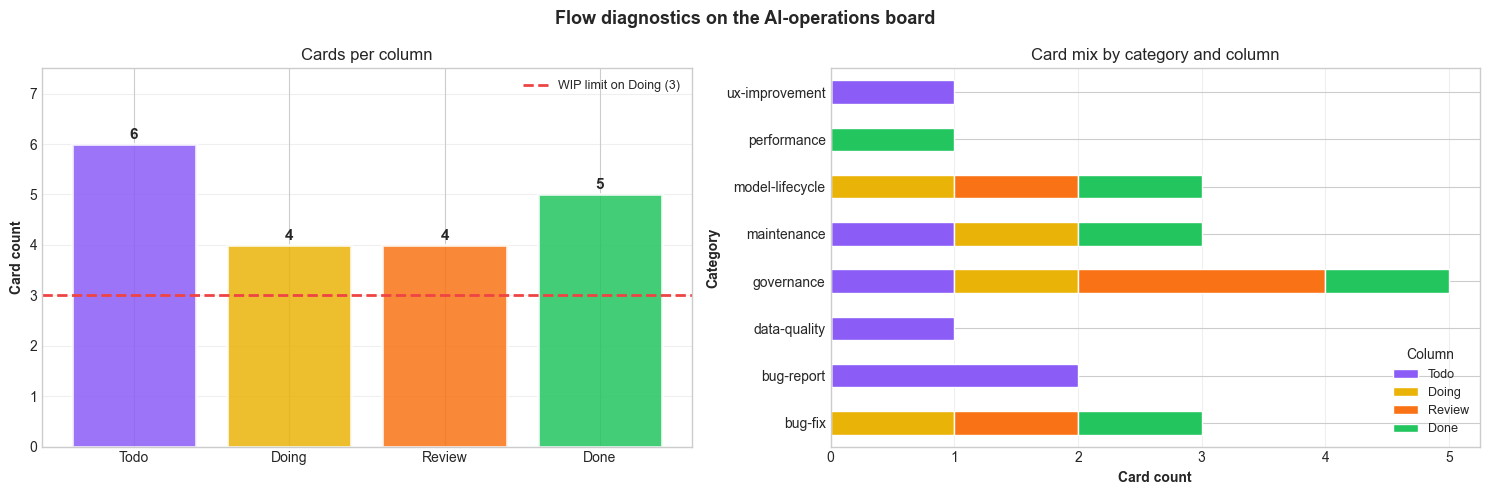

Saved: 03_ex_kanban_flow_diagnostics.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Flow diagnostics on the AI-operations board',
             fontsize=13, fontweight='bold')

col_colors = ['#8b5cf6', '#eab308', '#f97316', '#22c55e']
axes[0].bar(col_counts.index, col_counts.values, color=col_colors,
            alpha=0.85, edgecolor='white', linewidth=2)
axes[0].axhline(WIP_LIMIT_DOING, color='#ef4444', linestyle='--',
                linewidth=2, label=f'WIP limit on Doing ({WIP_LIMIT_DOING})')
for i, v in enumerate(col_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center',
                 fontweight='bold', fontsize=11)
axes[0].set_ylabel('Card count', fontweight='bold')
axes[0].set_title('Cards per column')
axes[0].set_ylim(0, max(col_counts.values) + 1.5)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

cat_by_col.plot(kind='barh', stacked=True, ax=axes[1],
                color=col_colors, edgecolor='white', linewidth=1)
axes[1].set_xlabel('Card count', fontweight='bold')
axes[1].set_ylabel('Category', fontweight='bold')
axes[1].set_title('Card mix by category and column')
axes[1].legend(title='Column', fontsize=9, loc='lower right')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('03_ex_kanban_flow_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_ex_kanban_flow_diagnostics.png')

## Part 4 — Workflow narrative

Three to five lines describing the represented workflow, in the spirit of the original brief.

> The board models the **continuous operations** of a production AI system rather than feature delivery. Cards enter **Todo** through several channels — user reports, internal audit requests, drift alerts, dependency-upgrade reminders. Engineers pull into **Doing** under a strict WIP limit (one card per engineer), preferring to swarm on a single in-flight item over multitasking. Once code or configuration is ready, the card moves to **Review**, where QA, validation, or compliance sign-off happens; for model changes, this includes explainability and bias checks before the version is approved. **Done** is the rolling history of completed work and feeds the team's throughput metrics. The current snapshot signals that **Review** is the constraint of the moment — four cards waiting vs three engineers actively working — so the team should prioritise clearing Review items before pulling new ones into Doing.

## Critical reading

A few observations on the framework and on this specific board.

**WIP limits are the method, not decoration.** Without a WIP limit on Doing the board is just a digital to-do list. The discipline of refusing to start new work when the column is full is what produces the observable benefits Kanban claims: shorter cycle time, surfaced bottlenecks, less context switching. Setting the limit at one card per engineer is a defensible starting point; tuning it is itself a feedback loop — too low and engineers stall waiting for a card, too high and the column becomes a graveyard of half-finished work.

**The current bottleneck is Review, not Doing.** Doing sits at four cards against a limit of three (one over), and Review sits at four cards. Naive reading says "Doing is overloaded". The Kanban reading is different: Review has accumulated as much as Doing, which means cards are spending non-trivial time waiting for QA / validation / compliance sign-off. Pulling another card from Todo into Doing would push Review even further. The right move is the opposite of intuition — *help Review first*, even at the cost of Doing engineers temporarily switching to review duties. This is the "stop starting, start finishing" mantra in practice.

**The card-type mix tells a strategic story.** Of 19 cards on the board, 4 are governance (audit, compliance, explainability) and 4 are bug-fix or bug-report. Roughly 40% of the team's attention is being absorbed by *responding to issues* — bugs from users, governance demands from internal stakeholders. Only one card relates to model improvement (the quarterly retraining run) and one to performance. A team in this configuration is operating in a *reactive* mode: they are maintaining the system but not advancing it. Over time this is unsustainable; either the underlying causes of bug reports get addressed (better testing, better monitoring), or feature debt accumulates while the team firefights.

**Kanban for AI-ops is the right tool for the right job.** As argued in [`notes/07`](../notes/07_project_management_methodologies.md), AI-ops work is irregular by nature — drift alerts, user reports, regulatory updates do not arrive on a sprint schedule. Scrum's fixed-cadence commitment ceremony would force the team to either over-commit on a slow week or be unable to absorb a real incident on a busy week. Kanban accepts the irregularity and optimises for flow and responsiveness instead. The trade-off is less ceremony-driven alignment: the team needs a separate forum (a weekly review, a monthly retrospective) to do the *strategic* conversations that Scrum's sprint reviews provide for free.

**What this snapshot does not capture.** A single board view shows *state*, not *flow*. Cycle time (how long a card takes from Todo to Done), throughput (cards completed per week), and the cumulative flow diagram (CFD) are the metrics that actually tell you whether the team is improving over time. A Kanban implementation that stops at the board misses most of the framework's value. In a follow-up exercise, the natural step would be to instrument the board with timestamps on column transitions and produce a CFD over a meaningful window — that is where the data-driven part of Kanban lives.